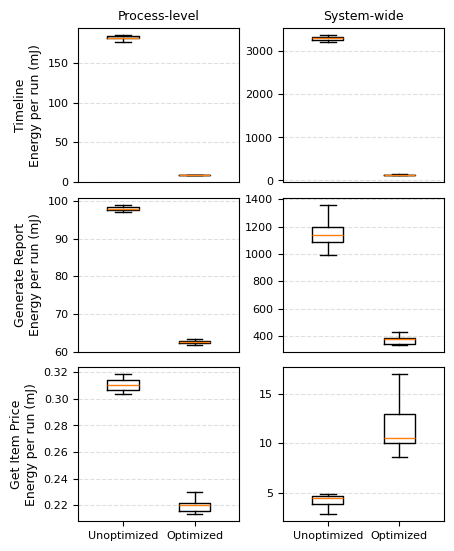

In [ ]:
# script to generate the plots for the three experiements reported in the paper
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


BASE = Path("../data/experiment_results_raw")

DATASETS = {
    "Timeline": (
        BASE / "energy_results_timeline_unoptimized.json",
        BASE / "energy_results_timeline_optimized.json",
    ),
    "Generate Report": (
        BASE / "energy_results_generate_report_unoptimized.json",
        BASE / "energy_results_generate_report_optimized.json",
    ),
    "Get Item Price": (
        BASE / "energy_results_get_item_price_unoptimized.json",
        BASE / "energy_results_get_item_price_optimized.json",
    ),
}


def load_trials(path, variant):
    with open(path) as f:
        trials = json.load(f)["trials"]
    df = pd.DataFrame(trials)
    df["variant"] = variant
    return df

def remove_outliers(x, lower_q=0.005, upper_q=0.995):
    lo, hi = np.quantile(x, [lower_q, upper_q])
    return x[(x >= lo) & (x <= hi)]


plt.rcParams.update({
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


fig, axes = plt.subplots(3, 2, figsize=(4.0, 5.7))

COL_TITLES = ["Process-level", "System-wide"]
METRICS = ["proc_energy_per_run_J", "net_sys_host_per_run_J"]

# Column headers
for col_idx, title in enumerate(COL_TITLES):
    axes[0, col_idx].set_title(title)


for row_idx, (experiment_name, (unopt_path, opt_path)) in enumerate(DATASETS.items()):

    df = pd.concat(
        [
            load_trials(unopt_path, "Unoptimized"),
            load_trials(opt_path, "Optimized"),
        ],
        ignore_index=True,
    )

    # Convert J → mJ
    for c in df.columns:
        if c.endswith("_J"):
            df[c.replace("_J", "_mJ")] = df[c] * 1000

    for col_idx, metric_base in enumerate(METRICS):

        metric = metric_base.replace("_J", "_mJ")

        x = df[df["variant"] == "Unoptimized"][metric].dropna().to_numpy()
        y = df[df["variant"] == "Optimized"][metric].dropna().to_numpy()

        x = remove_outliers(x)
        y = remove_outliers(y)

        ax = axes[row_idx, col_idx]

        positions = [1.0, 1.8]

        ax.boxplot(
            [x, y],
            positions=positions,
            widths=0.35,
            patch_artist=False,
            showfliers=False,
        )

        ax.margins(x=0.02)

        ax.grid(axis="y", linestyle="--", alpha=0.4)
        ax.set_axisbelow(True)

        if col_idx == 0:
            ax.set_ylabel(f"{experiment_name}\nEnergy per run (mJ)")
        else:
            ax.set_ylabel("")

        if row_idx == 2:
            ax.set_xticks(positions)
            ax.set_xticklabels(["Unoptimized", "Optimized"])
        else:
            ax.set_xticks([])



plt.subplots_adjust(
    left=0.08,
    right=0.995,
    top=0.94,
    bottom=0.075,
    hspace=0.1,
    wspace=0.27,
)


plt.show()